## 1. Import Necessary Library

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt

## 2. Data Collection

In [6]:
college_data = pd.read_csv("college_list.csv")
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


## 3. Data Understanding

In [7]:
college_data.shape

(500, 6)

In [8]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [9]:
college_data.dtypes

College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object

In [10]:
X = college_data.drop("College_Name",axis=1)

## 4. Data Preprocessing

In [11]:
std_scaller = StandardScaler()

In [17]:
scalled_X = std_scaller.fit_transform(X)
scalled_X = pd.DataFrame(scalled_X,columns=X.columns)

In [40]:
scalled_X.mean().round(),scalled_X.std().round()

(Student_Faculty_Ratio    0.0
 Annual_Fees_INR          0.0
 Placement_Percentage    -0.0
 Average_Package_LPA      0.0
 Infrastructure_Score    -0.0
 dtype: float64,
 Student_Faculty_Ratio    1.0
 Annual_Fees_INR          1.0
 Placement_Percentage     1.0
 Average_Package_LPA      1.0
 Infrastructure_Score     1.0
 dtype: float64)

## 5. Data Preprocessing

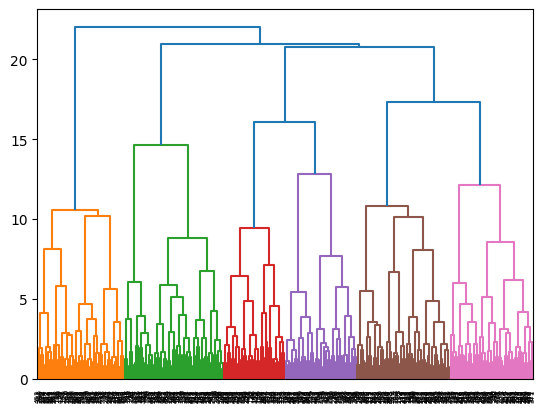

In [24]:
hierarchy.dendrogram(hierarchy.linkage(scalled_X,method='ward'))
plt.show()

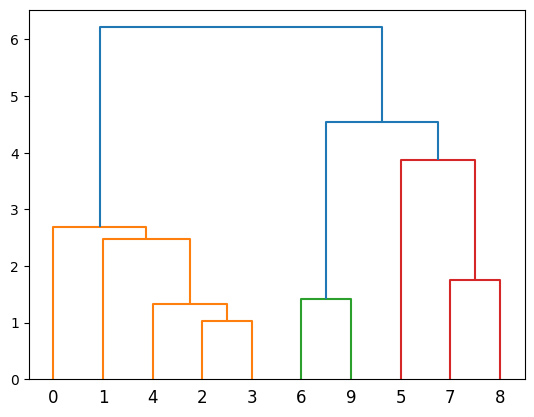

In [25]:
hierarchy.dendrogram(hierarchy.linkage(scalled_X.head(10),method='ward'))
plt.show()

## 6. Data Preparation

In [26]:
Clust_Module = AgglomerativeClustering(n_clusters=3,linkage='ward')

In [28]:
X["Category"] = Clust_Module.fit_predict(scalled_X)

In [41]:
college_data["Cluster_Category"] = Clust_Module.fit_predict(scalled_X)

In [29]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,Category
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0
496,12,39111,76,3.62,7,0
497,16,199182,64,3.88,3,1
498,10,46389,77,9.31,6,0


In [42]:
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,Cluster_Category
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [30]:
X.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,Category
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600,0.576000
std,6.683283,63928.678815,17.193465,2.917991,2.00486,0.803439
min,8.000000,30404.000000,40.000000,2.000000,3.00000,0.000000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000,0.000000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000,0.000000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000,1.000000
max,29.000000,249930.000000,99.000000,11.990000,9.00000,2.000000


## Data Mining

In [44]:
X.groupby(by = "Category").agg("mean")

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
Category,,,,,
0,20.407051,121853.471154,67.278846,6.954583,6.509615
1,17.159091,156795.136364,85.568182,5.565682,3.965909
2,11.650000,175656.000000,59.790000,8.362500,6.080000


In [45]:
X.groupby(by = "Category").agg(["min","max"])

Student_Faculty_Ratio     Annual_Fees_INR          ... Average_Package_LPA        Infrastructure_Score    
                           min max             min     max  ...                 min    max                  min max
Category                                                    ...                                                    
0                            8  29           30404  249536  ...                2.00  11.99                    3   9
1                            8  29           39337  248803  ...                2.09  11.96                    3   9
2                            8  20           49065  249930  ...                2.01  11.91                    3   9

[3 rows x 10 columns]

In [47]:
Module_Category = {0:"Emerging",
                   1:"Mid-Level",
                   2: "Best"}

X["College_Category"] = X["Category"].map(Module_Category)

In [48]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,Category,College_Category
0,14,113042,59,9.20,8,2,Best
1,27,115999,67,3.07,7,0,Emerging
2,22,47955,50,3.40,9,0,Emerging
3,18,67841,43,4.64,8,0,Emerging
4,15,100640,54,4.66,9,0,Emerging
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Emerging
496,12,39111,76,3.62,7,0,Emerging
497,16,199182,64,3.88,3,1,Mid-Level
498,10,46389,77,9.31,6,0,Emerging


In [51]:
Culuster_X = X.drop(["Category","College_Category"],axis=1)
y = X["Category"]

## Prediction

In [52]:
X_train,X_test,y_train,y_test = train_test_split(Culuster_X,y,shuffle=True,random_state=12,stratify=y,test_size=0.20)

In [53]:
rf_Module = RandomForestClassifier()

In [54]:
rf_Module.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
rf_Module.score(X_test,y_test)

0.92